### Fine-tuned Plasmid Annotation Analysis

#### 1. Function of this script
This script generates visualization figures for the fine-tuned plasmid generation analysis:
- Radar plots comparing part distributions across 10 different plasmid types (prompts 0-9)
- Bar plot showing top 10 vector types from Addgene database

#### 2. Input and Output
**Input files (in the same folder):**
- `top_10_vector_types.csv`: Pre-computed top 10 vector types with counts
- `radar_plot_data/prompt{0-9}_data.csv`: Part frequency data for each prompt type

Each radar data CSV should contain columns: 'Feature', 'Addgene', 'Generated', 'Addgene_prompt'

**Output:**
- 10 radar plots (one per prompt/plasmid type)
- Top 10 vector types bar plot

#### 3. Time estimation
- Total runtime: ~1 minute

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
import os

# Output folders
OUTPUT_FOLDER = "./figures"
DATA_FOLDER = "./radar_plot_data"

# Create output folders if they don't exist
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
os.makedirs(DATA_FOLDER, exist_ok=True)

# Prompt titles mapping
PROMPT_TITLES = {
    0: "Mammalian expression",
    1: "Bacterial expression",
    2: "Yeast expression",
    3: "Synthetic biology",
    4: "Lentiviral",
    5: "Insect expression",
    6: "Plant expression",
    7: "CRISPR",
    8: "Gateway Donor Vector",
    9: "AAV"
}

# Features for radar plot
FEATURES = ["RBS", "promoter", "terminator", "LTR", "CDS", "polyA_signal", "intron", "enhancer"]

# Maximum files to process
MAX_FILES = 2000


# =============================================================================
# Data Processing Functions
# =============================================================================

def get_part_count(folder_path, contain_str=''):
    """
    Count part types from pLannotate annotation CSV files.
    
    Parameters:
    -----------
    folder_path : str
        Path to folder containing annotation CSV files
    contain_str : str
        Filter string for file names
        
    Returns:
    --------
    tuple: (unique_words, word_counts, file_counts, feature_counts)
    """
    unique_words = set()
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            df = pd.read_csv(os.path.join(folder_path, file_name))
            if 'Type' in df.columns:
                unique_words.update(df['Type'].unique())

    # Count of unique words in each file
    word_counts = {word: 0 for word in unique_words}
    file_counts = 0
    feature_counts = []
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv') and contain_str in file_name:
            df = pd.read_csv(os.path.join(folder_path, file_name))
            file_counts = file_counts + 1
            if file_counts == MAX_FILES:
                break
            feature_counts.append(len(df))
            if 'Type' in df.columns:
                for word in df['Type'].unique():
                    if word in word_counts:
                        word_counts[word] += 1
                        
    return unique_words, word_counts, file_counts, feature_counts


def compute_radar_data(prompt_idx):
    """
    Compute radar plot data for a specific prompt.
    
    Parameters:
    -----------
    prompt_idx : int
        Prompt index (0-9)
        
    Returns:
    --------
    pd.DataFrame: DataFrame with columns Feature, Addgene, Generated, Addgene_prompt
    """
    # Get part counts for Addgene (baseline)
    _, word_counts, _, _ = get_part_count(ADDGENE_FOLDER)
    
    # Get part counts for generated plasmids
    _, word_counts2, _, _ = get_part_count(
        GENERATED_FOLDER, 
        contain_str=f"model30000_prompt{prompt_idx}"
    )
    
    # Get part counts for Addgene prompt-specific
    _, word_counts3, _, _ = get_part_count(
        ADDGENE_PROMPT_FOLDER, 
        contain_str=f"addgene_prompt{prompt_idx}"
    )
    
    # Get common keys
    keys_of_interest = list(np.intersect1d(
        list(word_counts.keys()), 
        list(word_counts2.keys())
    ))
    
    # Normalize counts
    total1 = sum(word_counts.values()) if sum(word_counts.values()) > 0 else 1
    total2 = sum(word_counts2.values()) if sum(word_counts2.values()) > 0 else 1
    total3 = sum(word_counts3.values()) if sum(word_counts3.values()) > 0 else 1
    
    filtered_dict1 = {key: word_counts.get(key, 0) / total1 for key in keys_of_interest}
    filtered_dict2 = {key: word_counts2.get(key, 0) / total2 for key in keys_of_interest}
    filtered_dict3 = {key: word_counts3.get(key, 0) / total3 for key in keys_of_interest}
    
    # Create DataFrame
    data = []
    for feature in FEATURES:
        data.append({
            'Feature': feature,
            'Addgene': filtered_dict1.get(feature, 0),
            'Generated': filtered_dict2.get(feature, 0),
            'Addgene_prompt': filtered_dict3.get(feature, 0)
        })
    
    return pd.DataFrame(data)


def compute_vector_type_data():
    """
    Compute top 10 vector types from Addgene metadata.
    
    Returns:
    --------
    pd.DataFrame: DataFrame with columns Vector Type, Count
    """
    # Read the CSV file
    df = pd.read_csv(ADDGENE_INFO_FILE, low_memory=False)
    
    def count_commas(text):
        # Convert to string in case the input is not a string (e.g., NaN or numeric)
        text = str(text)
        return text.count(',')
    
    # Apply the function to the 'Vector type' column to count commas
    df['comma_count'] = df['Vector type'].apply(count_commas)
    
    # Filter and get the top phrases for entries with no commas
    top_10_no_comma = df[df['comma_count'] == 0]['Vector type'].value_counts().head(10)
    
    # Convert Series to DataFrame for plotting
    top_10_no_comma_df = top_10_no_comma.reset_index()
    top_10_no_comma_df.columns = ['Vector Type', 'Count']
    
    return top_10_no_comma_df


# =============================================================================
# Plotting Functions
# =============================================================================

def plot_radar(data_df, title, save_path=None):
    """
    Plot radar chart comparing part distributions.
    
    Parameters:
    -----------
    data_df : pd.DataFrame
        DataFrame with columns: Feature, Addgene, Generated, Addgene_prompt
    title : str
        Title for the plot
    save_path : str, optional
        Path to save the figure
    """
    # Prepare data
    def prepare_data(df, col_name):
        return [df[df['Feature'] == feature][col_name].values[0] 
                if feature in df['Feature'].values else 0 
                for feature in FEATURES]
    
    data1 = prepare_data(data_df, 'Addgene')
    data2 = prepare_data(data_df, 'Generated')
    data3 = prepare_data(data_df, 'Addgene_prompt')
    
    # Close the radar chart by appending the first value to the end
    data1 += data1[:1]
    data2 += data2[:1]
    data3 += data3[:1]
    
    # Number of variables
    num_vars = len(FEATURES)
    
    # Angle for each axis
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]  # Complete the loop
    
    # Initialize the radar plot
    fig, ax = plt.subplots(figsize=(2, 2), subplot_kw={'polar': True})
    
    # Plot each dataset
    ax.plot(angles, data1, linewidth=1, linestyle='solid', label='Addgene')
    ax.fill(angles, data1, 'b', alpha=0.1)
    
    ax.plot(angles, data2, linewidth=1, linestyle='solid', label='Generated')
    ax.fill(angles, data2, 'r', alpha=0.1)
    
    ax.plot(angles, data3, linewidth=1, linestyle='solid', label='Addgene_prompt')
    ax.fill(angles, data3, 'g', alpha=0.1)
    
    # Font settings and custom ticks for angles
    plt.xticks(angles[:-1], FEATURES, color='black', size=7)
    
    # Custom radial ticks
    ax.set_rgrids(np.arange(0.04, 0.20, 0.04), angle=315, 
                  labels=[f"{x:.2f}" for x in np.arange(0.04, 0.20, 0.04)], fontsize=7)
    
    # Adjust tick parameters
    ax.tick_params(axis='x', which='major', labelsize=7)
    ax.tick_params(axis='y', which='major', labelsize=7)
    
    # Add title
    plt.title(title, fontsize=9, pad=10)
    
    # Save the plot
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=600)
        plt.savefig(save_path.replace('.png', '.svg'), bbox_inches='tight')
    
    plt.show()
    
    return fig


def plot_vector_type_barplot(data_df, save_path=None):
    """
    Plot bar chart for top 10 vector types.
    
    Parameters:
    -----------
    data_df : pd.DataFrame
        DataFrame with columns: Vector Type, Count
    save_path : str, optional
        Path to save the figure
    """
    plt.figure(figsize=(1.5, 1.5))
    sns.barplot(x='Count', y='Vector Type', data=data_df, 
                palette=sns.color_palette("tab10", n_colors=10))
    plt.xlabel('Vector Count', fontsize=7)
    plt.ylabel('', fontsize=7)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    
    # Save the plot
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=600)
        plt.savefig(save_path.replace('.png', '.eps'), bbox_inches='tight')
    
    plt.show()



Generating radar plots...


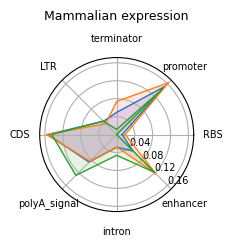

  Generated: ./figures\radar_plot_prompt0_Mammalian expression.png


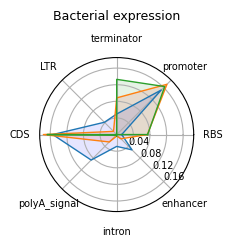

  Generated: ./figures\radar_plot_prompt1_Bacterial expression.png


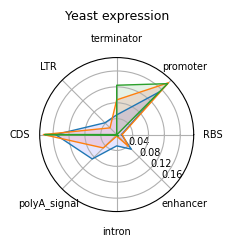

  Generated: ./figures\radar_plot_prompt2_Yeast expression.png


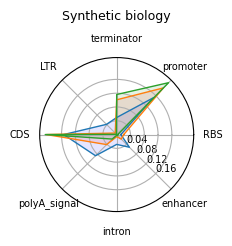

  Generated: ./figures\radar_plot_prompt3_Synthetic biology.png


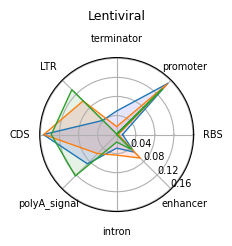

  Generated: ./figures\radar_plot_prompt4_Lentiviral.png


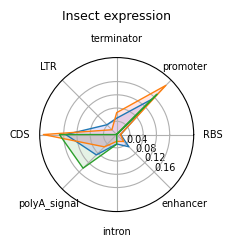

  Generated: ./figures\radar_plot_prompt5_Insect expression.png


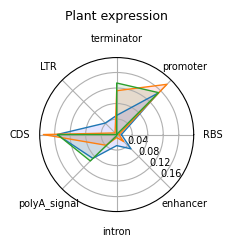

  Generated: ./figures\radar_plot_prompt6_Plant expression.png


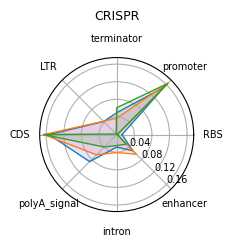

  Generated: ./figures\radar_plot_prompt7_CRISPR.png


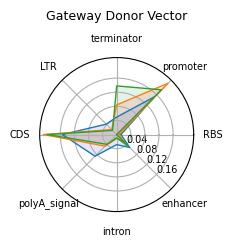

  Generated: ./figures\radar_plot_prompt8_Gateway Donor Vector.png


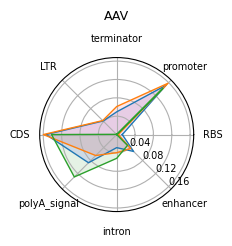

  Generated: ./figures\radar_plot_prompt9_AAV.png


In [7]:
print("\nGenerating radar plots...")
for prompt_idx in range(10):
    title = PROMPT_TITLES[prompt_idx]
    data_file = os.path.join(DATA_FOLDER, f"prompt{prompt_idx}_data.csv")
    
    if os.path.exists(data_file):
        data_df = pd.read_csv(data_file)
        save_path = os.path.join(OUTPUT_FOLDER, f"radar_plot_prompt{prompt_idx}_{title}.png")
        plot_radar(data_df, title, save_path)
        print(f"  Generated: {save_path}")
    else:
        print(f"  Data file not found: {data_file}")



Generating barplot...


C:\Users\shaob\AppData\Local\Temp\ipykernel_30260\307810743.py:255: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Vector Type', data=data_df,


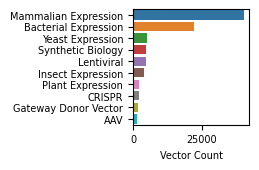

In [6]:
print("\nGenerating barplot...")
top_10_no_comma_df = pd.read_csv("top_10_vector_types.csv")

plot_vector_type_barplot(top_10_no_comma_df)